In [1]:
# setup

import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [2]:
# unzip data

zip_path = "/content/archive (8).zip"
extract_folder = "/content/olist"

os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_folder)

orders = pd.read_csv(f"{extract_folder}/olist_orders_dataset.csv")
items = pd.read_csv(f"{extract_folder}/olist_order_items_dataset.csv")
payments = pd.read_csv(f"{extract_folder}/olist_order_payments_dataset.csv")
reviews = pd.read_csv(f"{extract_folder}/olist_order_reviews_dataset.csv")

print("data loaded")

data loaded


In [3]:
# rebuild hw2 dataset

orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], errors="coerce")
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"], errors="coerce")
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"], errors="coerce")

items_agg = items.groupby("order_id").agg(
    n_items=("order_item_id", "max"),
    total_price=("price", "sum"),
    total_freight=("freight_value", "sum"),
    mean_price=("price", "mean")
).reset_index()

payments_agg = payments.groupby("order_id").agg(
    payment_value_sum=("payment_value", "sum"),
    payment_installments=("payment_installments", "max"),
    payment_type=("payment_type", lambda x: x.mode().iloc[0] if len(x.mode()) else np.nan)
).reset_index()

df = orders.merge(reviews[["order_id", "review_score"]], on="order_id", how="inner")
df = df.merge(items_agg, on="order_id", how="left")
df = df.merge(payments_agg, on="order_id", how="left")

df["is_positive_review"] = (df["review_score"] >= 4).astype(int)

df["delivery_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

df["delivery_vs_estimated"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

df["order_weekday"] = df["order_purchase_timestamp"].dt.weekday
df["order_month"] = df["order_purchase_timestamp"].dt.month

numeric_features = [
    "delivery_days",
    "delivery_vs_estimated",
    "total_price",
    "total_freight",
    "n_items",
    "payment_value_sum",
    "payment_installments",
    "mean_price",
    "order_weekday",
    "order_month"
]

categorical_features = ["payment_type"]

feature_cols = numeric_features + categorical_features
target = "is_positive_review"

X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", num_pipe, numeric_features),
    ("cat", cat_pipe, categorical_features)
])

model = Pipeline([
    ("preprocess", preprocess),
    ("model", HistGradientBoostingClassifier(max_depth=5, max_iter=200, random_state=42))
])

model.fit(X_train, y_train)

print("model trained")

model trained


In [4]:
# Part 5A production data simulation

train_df = X_train.copy()
train_df[target] = y_train.values

production_months = []

for month in range(1, 7):
    month_df = train_df.sample(n=3000, replace=True, random_state=42 + month).copy()
    month_df["month"] = month

    for col in ["delivery_days", "total_price", "total_freight"]:
        noise = np.random.uniform(0.95, 1.05, size=len(month_df))
        month_df[col] = month_df[col] * noise

    if month == 4:
        month_df["delivery_days"] = month_df["delivery_days"] + 2
        month_df["total_freight"] = month_df["total_freight"] * 1.15

    if month == 5:
        month_df["delivery_days"] = month_df["delivery_days"] + 4
        month_df["total_freight"] = month_df["total_freight"] * 1.30

    if month == 6:
        month_df["delivery_days"] = month_df["delivery_days"] + 6
        month_df["total_freight"] = month_df["total_freight"] * 1.50

    positive_idx = month_df[month_df[target] == 1].sample(frac=0.05, random_state=100 + month).index
    month_df.loc[positive_idx, target] = 0

    production_months.append(month_df)

prod_df = pd.concat(production_months, ignore_index=True)

prod_df.shape

(18000, 13)

In [5]:
# Part 5B PSI function

def calculate_psi(expected, actual, bins=10):
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()

    bin_edges = np.linspace(expected.min(), expected.max(), bins + 1)

    expected_counts, _ = np.histogram(expected, bins=bin_edges)
    actual_counts, _ = np.histogram(actual, bins=bin_edges)

    expected_pct = expected_counts / len(expected)
    actual_pct = actual_counts / len(actual)

    expected_pct = np.where(expected_pct == 0, 0.0001, expected_pct)
    actual_pct = np.where(actual_pct == 0, 0.0001, actual_pct)

    psi_value = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))

    return psi_value

drift_features = ["delivery_days", "total_price", "total_freight"]

psi_results = pd.DataFrame(index=drift_features)

for month in range(1, 7):
    month_df = prod_df[prod_df["month"] == month]
    values = []

    for feature in drift_features:
        value = calculate_psi(train_df[feature], month_df[feature])
        values.append(value)

    psi_results[f"Month {month}"] = values

psi_results

,Month 1,Month 2,Month 3,Month 4,Month 5,Month 6
delivery_days,0.001475,0.001347,0.000884,0.014351,0.057671,0.140681
total_price,0.001507,0.000563,0.000516,0.001575,0.000573,0.000563
total_freight,0.003376,0.000588,0.002264,0.002183,0.004124,0.004958


In [6]:
# Part 5B KS test

ks_rows = []

for month in range(1, 7):
    month_df = prod_df[prod_df["month"] == month]

    for feature in drift_features:
        stat, p_value = ks_2samp(train_df[feature].dropna(), month_df[feature].dropna())

        ks_rows.append({
            "Month": month,
            "Feature": feature,
            "KS Statistic": stat,
            "p-value": p_value,
            "Significant Drift": p_value < 0.05
        })

ks_results = pd.DataFrame(ks_rows)
ks_results

,Month,Feature,KS Statistic,p-value,Significant Drift
0,1,delivery_days,0.045744,1.495682e-05,True
1,1,total_price,0.028229,2.026996e-02,True
2,1,total_freight,0.026525,3.466587e-02,True
3,2,delivery_days,0.043046,5.836487e-05,True
4,2,total_price,0.016669,3.979404e-01,False
5,2,total_freight,0.034232,2.335610e-03,True
6,3,delivery_days,0.040257,2.222352e-04,True
7,3,total_price,0.032611,4.411875e-03,True
8,3,total_freight,0.024634,6.076565e-02,False
9,4,delivery_days,0.178623,1.336554e-78,True


In [7]:
# Part 5C performance monitoring

monthly_metrics = []

for month in range(1, 7):
    month_df = prod_df[prod_df["month"] == month]

    X_month = month_df[feature_cols]
    y_month = month_df[target]

    preds = model.predict(X_month)
    probs = model.predict_proba(X_month)[:, 1]

    monthly_metrics.append({
        "Month": month,
        "Accuracy": accuracy_score(y_month, preds),
        "F1": f1_score(y_month, preds),
        "AUC": roc_auc_score(y_month, probs)
    })

performance_df = pd.DataFrame(monthly_metrics)
performance_df

,Month,Accuracy,F1,AUC
0,1,0.772667,0.861213,0.702093
1,2,0.788667,0.872229,0.691216
2,3,0.777333,0.863506,0.695174
3,4,0.786333,0.869795,0.679228
4,5,0.780333,0.865428,0.703476
5,6,0.788000,0.871151,0.695491


In [8]:
# Part 5C performance drop

month1_f1 = performance_df.loc[performance_df["Month"] == 1, "F1"].values[0]
month6_f1 = performance_df.loc[performance_df["Month"] == 6, "F1"].values[0]

absolute_drop = month1_f1 - month6_f1
percent_drop = (absolute_drop / month1_f1) * 100

print("Month 1 F1:", month1_f1)
print("Month 6 F1:", month6_f1)
print("Absolute F1 drop:", absolute_drop)
print("Percent F1 drop:", percent_drop)

Month 1 F1: 0.8612128612128612
Month 6 F1: 0.8711507293354943
Absolute F1 drop: -0.009937868122633087
Percent F1 drop: -1.1539386567726604


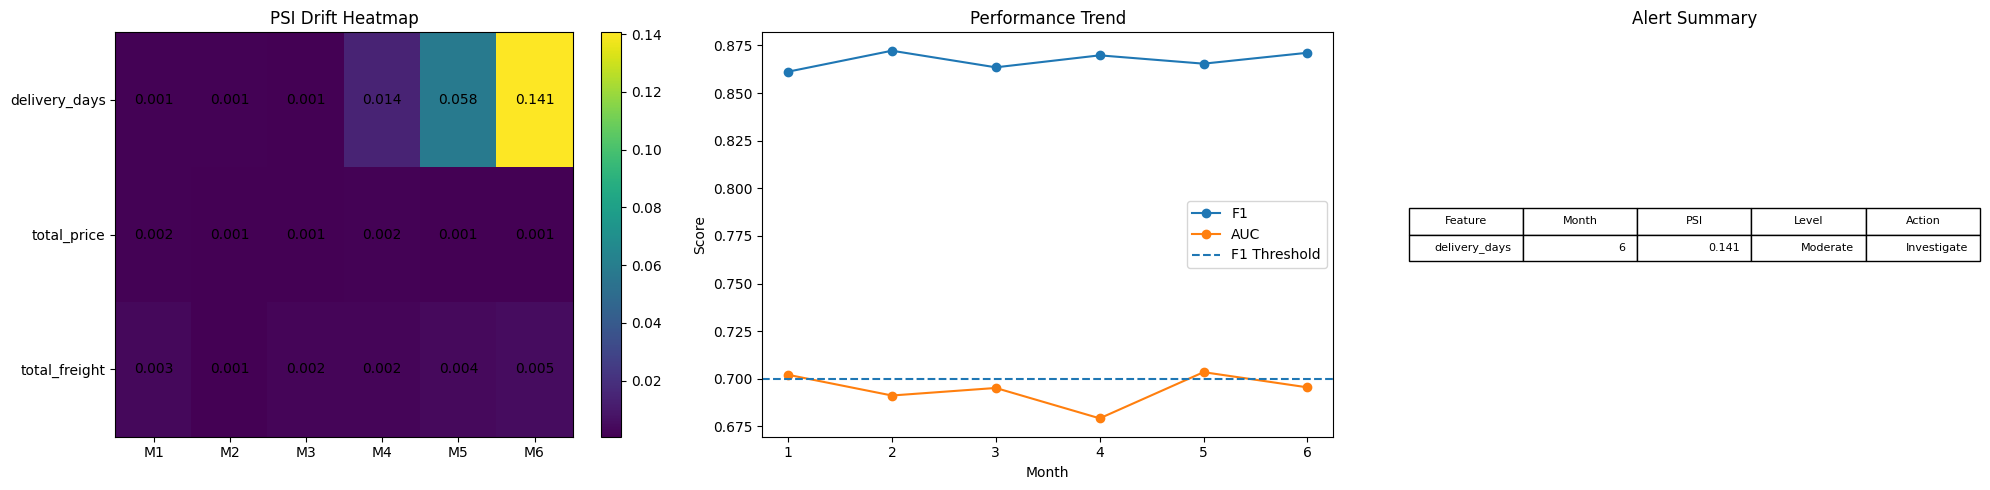

In [9]:
# Part 5D dashboard

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# panel 1 PSI heatmap
psi_values = psi_results.astype(float).values

im = axes[0].imshow(psi_values, aspect="auto")
axes[0].set_title("PSI Drift Heatmap")
axes[0].set_xticks(range(6))
axes[0].set_xticklabels([f"M{i}" for i in range(1, 7)])
axes[0].set_yticks(range(len(drift_features)))
axes[0].set_yticklabels(drift_features)

for i in range(len(drift_features)):
    for j in range(6):
        axes[0].text(j, i, round(psi_values[i, j], 3), ha="center", va="center")

plt.colorbar(im, ax=axes[0])

# panel 2 performance trend
axes[1].plot(performance_df["Month"], performance_df["F1"], marker="o", label="F1")
axes[1].plot(performance_df["Month"], performance_df["AUC"], marker="o", label="AUC")
axes[1].axhline(0.70, linestyle="--", label="F1 Threshold")
axes[1].set_title("Performance Trend")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Score")
axes[1].legend()

# panel 3 alert table
alerts = []

for feature in drift_features:
    for month in range(1, 7):
        value = psi_results.loc[feature, f"Month {month}"]

        if value >= 0.2:
            level = "Significant"
            action = "Retrain"
        elif value >= 0.1:
            level = "Moderate"
            action = "Investigate"
        else:
            continue

        alerts.append([feature, month, round(value, 3), level, action])

if len(alerts) == 0:
    alerts = [["None", "-", "-", "No major drift", "Monitor"]]

axes[2].axis("off")
table = axes[2].table(
    cellText=alerts,
    colLabels=["Feature", "Month", "PSI", "Level", "Action"],
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)
axes[2].set_title("Alert Summary")

plt.tight_layout()
plt.show()

# 5E Recommendation

Based on the monitoring results, I would recommend investigating the model when PSI reaches values above 0.1 and retraining when PSI exceeds 0.2 or when performance begins to decline. In this simulation, delivery_days reached a PSI of about 0.14 in Month 6, which indicates moderate drift. However, model performance remained stable and even slightly improved, so retraining is not immediately necessary.

I would continue monitoring the model closely and collect more recent production data before deciding to retrain. If drift continues to increase or if performance starts to decrease, I would retrain the model using the most recent data to reflect updated delivery patterns and customer behavior. As a next step, I would recommend setting up automated monitoring to track both drift and performance on a regular basis.